# Can a Bard Hear Doppler in a Charging Fighter’s War Cry?

A D&D-flavored walk through the **Doppler effect**: how much pitch shift humans can notice, how fast a sound source must move to produce it, and whether a bard could hear that rise when a fighter charges straight at them.

We assume ideal listening throughout — steady tone, head-on approach, calm air at ~20 °C — then plug in common D&D movement speeds at the end.


## 1. The Doppler effect

When a sound source moves toward you, successive wavefronts are packed closer together, so the frequency you hear goes **up**. When it moves away, wavefronts stretch out, and the pitch goes **down**. That is the Doppler effect — the same reason a siren drops in pitch as an ambulance passes.

For a **stationary listener** and a **moving source** (classic “siren on a vehicle” case),

$$
f' = f \cdot \frac{v}{v \mp v_s}
$$

- $v$: speed of sound in air
- $v_s$: source speed along the line of sight
- minus (−) when the source **approaches** (pitch rises)
- plus (+) when the source **recedes** (pitch falls)

This is the usual textbook form (e.g. [HyperPhysics](https://hyperphysics.gsu.edu/hbase/Sound/dopp.html), [Wikipedia](https://en.wikipedia.org/wiki/Doppler_effect)). The shift depends only on the **ratio** $v_s / v$, not on the original note $f$. So once we know how small a frequency ratio humans can hear, we can turn the formula around and ask: *how fast must the source move?*


### Speed of sound in air

In dry air near sea level,

$$
v(T) \approx 331.3 \sqrt{1 + \frac{T_{^\circ\mathrm{C}}}{273.15}} \;\mathrm{m/s}
$$

At a comfortable 20 °C that is about **343 m/s** — our default below. The same relation appears in compact form as $v \approx 331\sqrt{1 + T_C/273}\,\mathrm{m/s}$ in [OpenStax](https://openstax.org/books/university-physics-volume-1/pages/17-2-speed-of-sound), with the familiar checkpoints ≈331 m/s at 0 °C and ≈343 m/s at 20 °C on [HyperPhysics](https://hyperphysics.gsu.edu/hbase/Sound/souspe.html).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def speed_of_sound(temp_c: float | np.ndarray) -> float | np.ndarray:
    """Speed of sound in dry air [m/s] from temperature in Celsius."""
    return 331.3 * np.sqrt(1.0 + np.asarray(temp_c, dtype=float) / 273.15)


def mps_to_kmh(mps: float | np.ndarray) -> float | np.ndarray:
    return np.asarray(mps) * 3.6


def feet_per_round_to_mps(feet: float, round_s: float = 6.0) -> float:
    """Convert D&D feet-per-round into m/s (1 round = 6 s, 1 ft = 0.3048 m)."""
    return feet * 0.3048 / round_s


v20 = float(speed_of_sound(20.0))
print(f"Speed of sound at 20 C: {v20:.2f} m/s ({mps_to_kmh(v20):.0f} km/h)")

temps_c = np.linspace(-20, 40, 13)
for t in temps_c[::3]:
    print(f"T = {t:5.1f} C  ->  v = {speed_of_sound(t):6.2f} m/s")


Speed of sound at 20 C: 343.21 m/s (1236 km/h)
T = -20.0 C  ->  v = 318.94 m/s
T =  -5.0 C  ->  v = 328.25 m/s
T =  10.0 C  ->  v = 337.31 m/s
T =  25.0 C  ->  v = 346.13 m/s
T =  40.0 C  ->  v = 354.73 m/s


## 2. The smallest pitch difference humans can hear

Musicians measure pitch intervals in **cents**: 1 octave = 1200 cents, and one **semitone** (C → C♯) = **100 cents** ([HyperPhysics](http://hyperphysics.phy-astr.gsu.edu/hbase/Music/cents.html), [Wikipedia](https://en.wikipedia.org/wiki/Cent_(music))). In equal temperament, a shift of $c$ cents is the frequency ratio

$$
r = 2^{c/1200},
$$

so one semitone ($c = 100$) is $r = 2^{100/1200} = 2^{1/12} \approx 1.0595$. (Same idea: an octave doubles frequency, and equal temperament splits that octave into 12 equal semitone steps.)

Under good listening conditions, the **just-noticeable difference (JND)** in pitch is often around **~5 cents** — roughly 1/20 of a semitone. [HyperPhysics](http://hyperphysics.phy-astr.gsu.edu/hbase/Music/cents.html) calls five cents “a reasonable estimate,” and we use that as the bar for “I can tell the pitch moved.” A full semitone (100 cents) is the bar for “that is clearly a different note.”

| Threshold | Cents | Frequency ratio | Meaning |
|-----------|-------|-----------------|---------|
| Just-noticeable (JND) | ~5 | ≈ 1.0029 | “I can tell the pitch moved” |
| One semitone | 100 | ≈ 1.0595 | “That is clearly a different note” |


In [2]:
# Pitch-interval helpers
# CENTS_JND ~5: HyperPhysics Music/cents.html; Wikipedia Just-noticeable difference
CENTS_JND = 5.0
R_JND = 2 ** (CENTS_JND / 1200)
R_SEMITONE = 2 ** (1 / 12)

print(f"JND (~{CENTS_JND:.0f} cents):     r = {R_JND:.6f}")
print(f"One semitone (100 cents): r = {R_SEMITONE:.6f}")
print(f"One semitone in cents:    {1200 * np.log2(R_SEMITONE):.1f}")


JND (~5 cents):     r = 1.002892
One semitone (100 cents): r = 1.059463
One semitone in cents:    100.0


### Hear the difference

Each clip plays a **reference tone** (A₄ = 440 Hz), a short gap, then a **second tone**. Use headphones if you can, and listen for whether the second note feels the same, slightly sharp, or clearly a different pitch.

- **Unison** — same pitch twice (control)
- **+5 / +10 / +20 / +50 cents** — from “barely moved” toward “obviously sharp”
- **+100 cents (one semitone)** — C → C♯ territory


In [3]:
from IPython.display import Audio, display, Markdown

# Browser HTML5 audio via IPython — works on Windows / macOS / Linux in Jupyter
# (no PortAudio / sounddevice install required).

SR = 44_100
REF_HZ = 440.0  # A4


def sine_tone(freq_hz: float, duration_s: float = 0.85, amp: float = 0.28) -> np.ndarray:
    """Pure tone with short fade in/out to avoid clicks."""
    n = int(SR * duration_s)
    t = np.arange(n) / SR
    wave = amp * np.sin(2.0 * np.pi * freq_hz * t)
    fade = max(1, int(0.02 * SR))
    env = np.ones(n)
    env[:fade] = np.linspace(0.0, 1.0, fade)
    env[-fade:] = np.linspace(1.0, 0.0, fade)
    return wave * env


def ab_clip(freq_a: float, freq_b: float, gap_s: float = 0.35) -> np.ndarray:
    """Reference tone A, silence, then tone B."""
    gap = np.zeros(int(SR * gap_s))
    return np.concatenate([sine_tone(freq_a), gap, sine_tone(freq_b)])


def hz_from_cents(cents: float, ref_hz: float = REF_HZ) -> float:
    return ref_hz * (2.0 ** (cents / 1200.0))


demos = [
    ("Unison (0 cents)", 0.0),
    (f"+{CENTS_JND:.0f} cents (JND)", CENTS_JND),
    ("+10 cents", 10.0),
    ("+20 cents", 20.0),
    ("+50 cents (quarter tone-ish)", 50.0),
    ("+100 cents (one semitone)", 100.0),
]

for label, cents in demos:
    f_b = hz_from_cents(cents)
    clip = ab_clip(REF_HZ, f_b)
    display(Markdown(
        f"**{label}** — second tone at {f_b:.2f} Hz "
        f"(ratio r = {f_b / REF_HZ:.6f})"
    ))
    display(Audio(clip, rate=SR, normalize=False))


**Unison (0 cents)** — second tone at 440.00 Hz (ratio r = 1.000000)

**+5 cents (JND)** — second tone at 441.27 Hz (ratio r = 1.002892)

**+10 cents** — second tone at 442.55 Hz (ratio r = 1.005793)

**+20 cents** — second tone at 445.11 Hz (ratio r = 1.011619)

**+50 cents (quarter tone-ish)** — second tone at 452.89 Hz (ratio r = 1.029302)

**+100 cents (one semitone)** — second tone at 466.16 Hz (ratio r = 1.059463)

## 3. How fast must the source move?

Invert the Doppler formula for a chosen frequency ratio $r = f'/f$:

**Approaching** (heard higher):

$$
\frac{v}{v - v_s} = r \quad\Rightarrow\quad v_s^{\mathrm{approach}} = v\left(1 - \frac{1}{r}\right)
$$

**Receding** (heard lower):

$$
\frac{v}{v + v_s} = \frac{1}{r} \quad\Rightarrow\quad v_s^{\mathrm{recede}} = v\,(r - 1)
$$

Approach and recession are **not** symmetric: a given fractional pitch change needs slightly less speed when approaching than when receding.


In [4]:
def vs_for_ratio_approach(v: float | np.ndarray, r: float) -> float | np.ndarray:
    """Source speed [m/s] for frequency ratio r when approaching."""
    return np.asarray(v) * (1.0 - 1.0 / r)


def vs_for_ratio_recede(v: float | np.ndarray, r: float) -> float | np.ndarray:
    """Source speed [m/s] for frequency ratio 1/r when receding."""
    return np.asarray(v) * (r - 1.0)


def pitch_shift_cents(vs: float | np.ndarray, v: float, approaching: bool = True) -> float | np.ndarray:
    """Observed pitch shift in cents for source speed vs."""
    vs = np.asarray(vs, dtype=float)
    ratio = v / (v - vs) if approaching else v / (v + vs)
    return 1200.0 * np.log2(ratio)


def pitch_shift_semitones(vs: float | np.ndarray, v: float, approaching: bool = True) -> float | np.ndarray:
    return np.asarray(pitch_shift_cents(vs, v, approaching=approaching)) / 100.0


# Thresholds at 20 C
vs_jnd_app = float(vs_for_ratio_approach(v20, R_JND))
vs_jnd_rec = float(vs_for_ratio_recede(v20, R_JND))
vs_semi_app = float(vs_for_ratio_approach(v20, R_SEMITONE))
vs_semi_rec = float(vs_for_ratio_recede(v20, R_SEMITONE))

print(f"At 20 C (v = {v20:.2f} m/s):")
print()
print("Just-noticeable (~5 cents):")
print(f"  Approaching: {vs_jnd_app:.2f} m/s  = {mps_to_kmh(vs_jnd_app):.1f} km/h")
print(f"  Receding:    {vs_jnd_rec:.2f} m/s  = {mps_to_kmh(vs_jnd_rec):.1f} km/h")
print()
print("One full semitone (100 cents):")
print(f"  Approaching: {vs_semi_app:.2f} m/s  = {mps_to_kmh(vs_semi_app):.1f} km/h")
print(f"  Receding:    {vs_semi_rec:.2f} m/s  = {mps_to_kmh(vs_semi_rec):.1f} km/h")


At 20 C (v = 343.21 m/s):

Just-noticeable (~5 cents):
  Approaching: 0.99 m/s  = 3.6 km/h
  Receding:    0.99 m/s  = 3.6 km/h

One full semitone (100 cents):
  Approaching: 19.26 m/s  = 69.3 km/h
  Receding:    20.41 m/s  = 73.5 km/h


### Pitch shift vs source speed

How many cents of pitch shift you get as speed increases. Horizontal guides mark the ~5-cent JND and the full semitone.


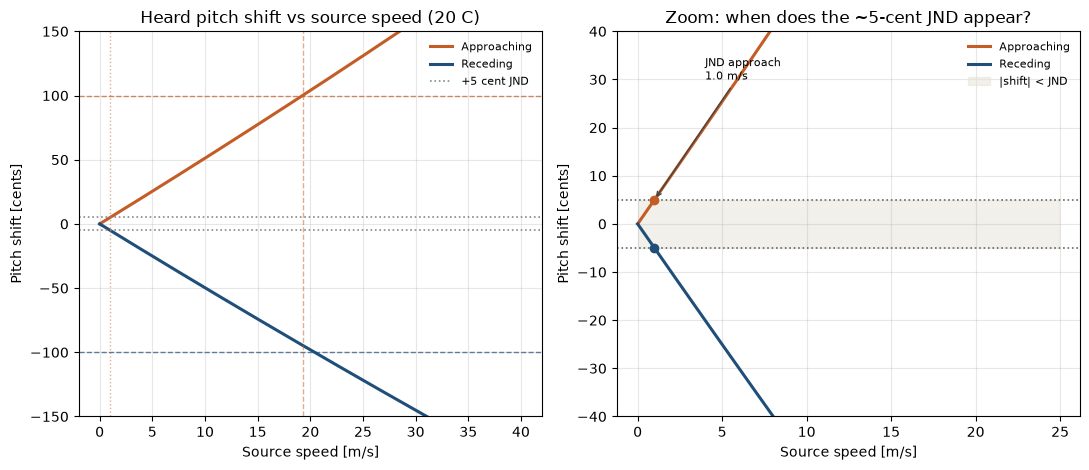

In [5]:
vs = np.linspace(0, 40, 500)
cents_app = pitch_shift_cents(vs, v20, approaching=True)
cents_rec = pitch_shift_cents(vs, v20, approaching=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

ax = axes[0]
ax.plot(vs, cents_app, color="#c45c26", lw=2.2, label="Approaching")
ax.plot(vs, cents_rec, color="#1f4e79", lw=2.2, label="Receding")
ax.axhline(CENTS_JND, color="#888888", ls=":", lw=1.2, label=f"+{CENTS_JND:.0f} cent JND")
ax.axhline(-CENTS_JND, color="#888888", ls=":", lw=1.2)
ax.axhline(100, color="#c45c26", ls="--", lw=1, alpha=0.7)
ax.axhline(-100, color="#1f4e79", ls="--", lw=1, alpha=0.7)
ax.axvline(vs_jnd_app, color="#c45c26", ls=":", lw=1, alpha=0.5)
ax.axvline(vs_semi_app, color="#c45c26", ls="--", lw=1, alpha=0.5)
ax.set_xlabel("Source speed [m/s]")
ax.set_ylabel("Pitch shift [cents]")
ax.set_title("Heard pitch shift vs source speed (20 C)")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-150, 150)

ax = axes[1]
mask = vs <= 25
ax.plot(vs[mask], cents_app[mask], color="#c45c26", lw=2.2, label="Approaching")
ax.plot(vs[mask], cents_rec[mask], color="#1f4e79", lw=2.2, label="Receding")
ax.axhline(CENTS_JND, color="#666666", ls=":", lw=1.2)
ax.axhline(-CENTS_JND, color="#666666", ls=":", lw=1.2)
ax.fill_between(vs[mask], -CENTS_JND, CENTS_JND, color="#e8e4dc", alpha=0.55, label="|shift| < JND")
ax.scatter([vs_jnd_app], [CENTS_JND], color="#c45c26", zorder=5)
ax.scatter([vs_jnd_rec], [-CENTS_JND], color="#1f4e79", zorder=5)
ax.annotate(
    f"JND approach\n{vs_jnd_app:.1f} m/s",
    xy=(vs_jnd_app, CENTS_JND),
    xytext=(vs_jnd_app + 3, CENTS_JND + 25),
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="#444444"),
)
ax.set_xlabel("Source speed [m/s]")
ax.set_ylabel("Pitch shift [cents]")
ax.set_title("Zoom: when does the ~5-cent JND appear?")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-40, 40)

fig.tight_layout()
plt.show()


### Everyday speed comparisons

How do those threshold speeds feel in daily life?

A keen ear’s ~5-cent JND is only about **1 m/s** — ordinary walking. A full musical semitone is much harder: about **19–20 m/s**, which is city-driving territory (~70 km/h).

Human sprinting sits in between. An average adult’s 100 m is often around **15–16 s** (~6.5 m/s); an Olympic-level 100 m is about **10 s** (~10 m/s). Both are clearly audible as a pitch rise, but still well short of a whole semitone. Put the other way: at one-semitone speed you would cover 100 m in about **5 s** ($t = 100 / v_s$) — faster than any human sprinter.

The chart below lines those paces up with walking, bikes, and cars.


Doppler thresholds as equivalent 100 m times (t = 100 / v_s):
  +5 cent JND:  0.99 m/s  ->  101 s for 100 m
  +1 semitone:     19.26 m/s  ->  5.2 s for 100 m

What pitch rise would a 100 m sprint pace produce (approaching)?
  Avg adult (~16 s, 6.5 m/s): +32.9 cents  (0.33 semitones)
  Olympic (~10 s, 10.0 m/s): +51.2 cents  (0.51 semitones)



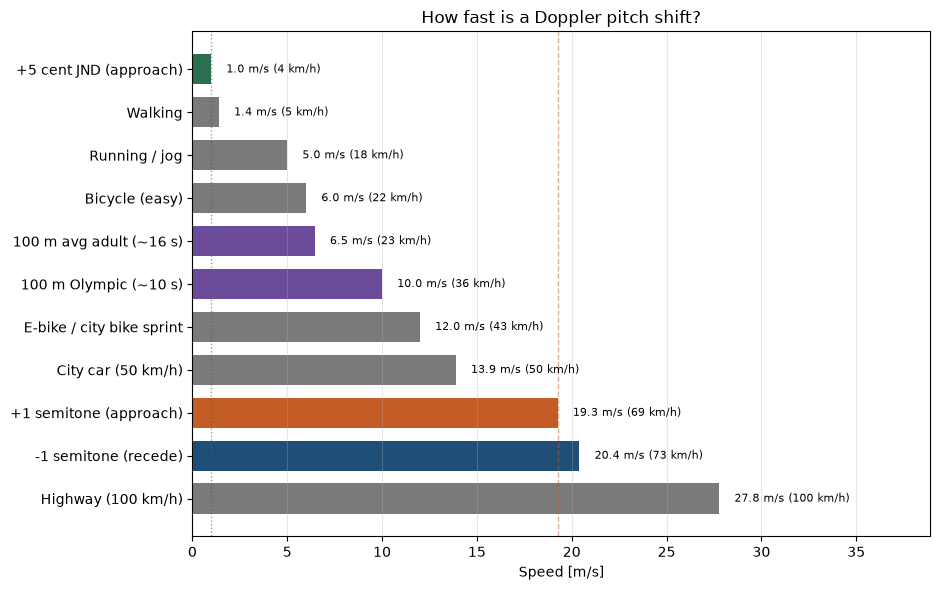

In [6]:
# 100 m sprint reference paces (mean speed over the race)
# Olympic / elite ~9.5–10.5 s; typical untrained adult ~14–18 s
T_100M_OLYMPIC_S = 10.0
T_100M_AVG_ADULT_S = 15.5
V_100M_OLYMPIC = 100.0 / T_100M_OLYMPIC_S
V_100M_AVG_ADULT = 100.0 / T_100M_AVG_ADULT_S


def time_for_100m(mps: float) -> float:
    """Seconds to cover 100 m at constant speed mps."""
    return 100.0 / mps


print("Doppler thresholds as equivalent 100 m times (t = 100 / v_s):")
print(f"  +{CENTS_JND:.0f} cent JND:  {vs_jnd_app:.2f} m/s  ->  {time_for_100m(vs_jnd_app):.0f} s for 100 m")
print(f"  +1 semitone:     {vs_semi_app:.2f} m/s  ->  {time_for_100m(vs_semi_app):.1f} s for 100 m")
print()
print("What pitch rise would a 100 m sprint pace produce (approaching)?")
for name, t_s, v_mps in [
    ("Avg adult", T_100M_AVG_ADULT_S, V_100M_AVG_ADULT),
    ("Olympic", T_100M_OLYMPIC_S, V_100M_OLYMPIC),
]:
    cents = float(pitch_shift_cents(v_mps, v20, approaching=True))
    print(
        f"  {name} (~{t_s:.0f} s, {v_mps:.1f} m/s): "
        f"+{cents:.1f} cents  ({cents/100:.2f} semitones)"
    )
print()

comparisons = [
    ("Walking", 1.4),
    ("Running / jog", 5.0),
    ("Bicycle (easy)", 6.0),
    (f"100 m avg adult (~{T_100M_AVG_ADULT_S:.0f} s)", V_100M_AVG_ADULT),
    (f"+{CENTS_JND:.0f} cent JND (approach)", vs_jnd_app),
    (f"100 m Olympic (~{T_100M_OLYMPIC_S:.0f} s)", V_100M_OLYMPIC),
    ("E-bike / city bike sprint", 12.0),
    ("+1 semitone (approach)", vs_semi_app),
    ("-1 semitone (recede)", vs_semi_rec),
    ("City car (50 km/h)", 50 / 3.6),
    ("Highway (100 km/h)", 100 / 3.6),
]

# Keep chart ordered by speed for readability
comparisons = sorted(comparisons, key=lambda c: c[1])

labels = [c[0] for c in comparisons]
speeds = np.array([c[1] for c in comparisons])
colors = []
for name, _ in comparisons:
    if "JND" in name:
        colors.append("#2a6f4e")
    elif "semitone" in name and "approach" in name:
        colors.append("#c45c26")
    elif "semitone" in name:
        colors.append("#1f4e79")
    elif "100 m" in name:
        colors.append("#6b4c9a")
    else:
        colors.append("#7a7a7a")

fig, ax = plt.subplots(figsize=(9.5, 6.0))
y = np.arange(len(labels))
ax.barh(y, speeds, color=colors, height=0.7)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Speed [m/s]")
ax.set_title("How fast is a Doppler pitch shift?")
ax.axvline(vs_jnd_app, color="#2a6f4e", ls=":", lw=1, alpha=0.6)
ax.axvline(vs_semi_app, color="#c45c26", ls="--", lw=1, alpha=0.5)

for yi, s in zip(y, speeds):
    ax.text(s + 0.8, yi, f"{s:.1f} m/s ({mps_to_kmh(s):.0f} km/h)", va="center", fontsize=8)

ax.set_xlim(0, max(speeds) * 1.4)
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
plt.show()


### Temperature and Mach number (optional detail)

Because the Doppler shift depends on $M = v_s / v$, the **Mach fraction** for a given pitch change is temperature-independent. Absolute speed in m/s scales gently with air temperature.


Mach for +5 cent JND (approach): 0.00288  (0.29% of sound speed)
Mach for +1 semitone (approach):            0.05613  (5.61% of sound speed)


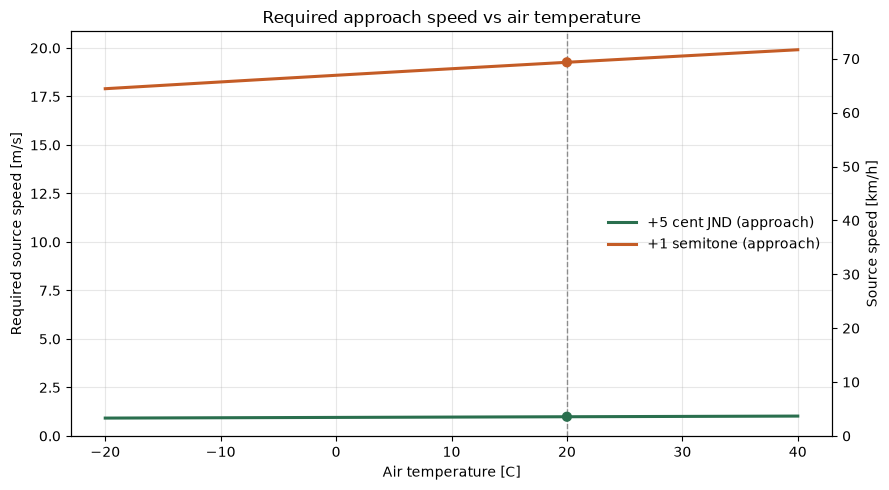

In [7]:
temps = np.linspace(-20, 40, 200)
v = speed_of_sound(temps)
vs_jnd_curve = vs_for_ratio_approach(v, R_JND)
vs_semi_curve = vs_for_ratio_approach(v, R_SEMITONE)

M_jnd = 1.0 - 1.0 / R_JND
M_semi = 1.0 - 1.0 / R_SEMITONE
print(f"Mach for +{CENTS_JND:.0f} cent JND (approach): {M_jnd:.5f}  ({100 * M_jnd:.2f}% of sound speed)")
print(f"Mach for +1 semitone (approach):            {M_semi:.5f}  ({100 * M_semi:.2f}% of sound speed)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(temps, vs_jnd_curve, color="#2a6f4e", lw=2.2, label=f"+{CENTS_JND:.0f} cent JND (approach)")
ax.plot(temps, vs_semi_curve, color="#c45c26", lw=2.2, label="+1 semitone (approach)")
ax.axvline(20, color="#666666", ls="--", lw=1, alpha=0.7)
ax.scatter([20, 20], [vs_jnd_app, vs_semi_app], color=["#2a6f4e", "#c45c26"], zorder=5, s=40)
ax.set_xlabel("Air temperature [C]")
ax.set_ylabel("Required source speed [m/s]")
ax.set_title("Required approach speed vs air temperature")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
ymin, ymax = ax.get_ylim()
ax2.set_ylim(ymin * 3.6, ymax * 3.6)
ax2.set_ylabel("Source speed [km/h]")

fig.tight_layout()
plt.show()


## 4. Back to the bard: can they hear a charging fighter?

In D&D 5e, a [combat round](https://www.5esrd.com/gamemastering/combat/) is about **6 seconds**, and a typical [human](https://www.5esrd.com/races/human/) walks **30 feet** per round. Taking the **Dash** action doubles the distance covered that turn (30 → 60 feet). Spells and features like *Haste*, *Mobile*, or a Tabaxi’s Feline Agility can push that higher — but start with the common cases.

With **1 ft = 0.3048 m** exactly ([NIST](https://www.nist.gov/pml/owm/si-units-length)),

$$
v = \frac{(\text{feet per round}) \times 0.3048}{6}\;\mathrm{m/s}
$$

so 30 ft/round ≈ **1.5 m/s**, and a Dash charge at 60 ft/round ≈ **3.0 m/s**. A few faster “what if?” rows below (horse Dash, *Haste*, big magic bursts) show how pitch rise scales if the charge gets quicker.


In [8]:
# Common D&D movement profiles (feet per 6-second round)
# Round=6s, Dash: 5e SRD Combat; 30 ft human walk: 5e SRD Human race
# https://www.5esrd.com/gamemastering/combat/
# https://www.5esrd.com/races/human/
dnd_profiles = [
    ("Walk 30 ft (no Dash)", 30),
    ("Dash charge 60 ft", 60),
    ("Fast race / Mobile 40 ft + Dash", 80),
    ("Haste 30 ft (speed×2) + Dash", 120),
    ("Tabaxi Feline Agility burst (illustrative)", 120),
    ("Horse Dash ~120 ft", 120),
    ("Very fast mount / magic burst", 240),
]

print(f"{'Scenario':<42} {'ft/rd':>6} {'m/s':>7} {'km/h':>7} {'cents↑':>8} {'hear JND?':>10}")
print("-" * 85)

rows = []
for name, feet in dnd_profiles:
    mps = feet_per_round_to_mps(feet)
    cents = float(pitch_shift_cents(mps, v20, approaching=True))
    hear = "yes" if cents >= CENTS_JND else "no"
    rows.append((name, feet, mps, cents, hear))
    print(f"{name:<42} {feet:6.0f} {mps:7.2f} {mps_to_kmh(mps):7.1f} {cents:8.2f} {hear:>10}")

print()
print(f"JND threshold (~{CENTS_JND:.0f} cents): need ~{vs_jnd_app:.2f} m/s approaching")
print(f"One-semitone threshold: 100 cents ->  need ~{vs_semi_app:.2f} m/s approaching")


Scenario                                    ft/rd     m/s    km/h   cents↑  hear JND?
-------------------------------------------------------------------------------------
Walk 30 ft (no Dash)                           30    1.52     5.5     7.70        yes
Dash charge 60 ft                              60    3.05    11.0    15.44        yes
Fast race / Mobile 40 ft + Dash                80    4.06    14.6    20.62        yes
Haste 30 ft (speed×2) + Dash                  120    6.10    21.9    31.03        yes
Tabaxi Feline Agility burst (illustrative)    120    6.10    21.9    31.03        yes
Horse Dash ~120 ft                            120    6.10    21.9    31.03        yes
Very fast mount / magic burst                 240   12.19    43.9    62.62        yes

JND threshold (~5 cents): need ~0.99 m/s approaching
One-semitone threshold: 100 cents ->  need ~19.26 m/s approaching


### The bard’s ear vs the fighter’s charge

The fighter runs **straight at** the bard and holds a steady war cry. Compare the Doppler cents from common charges to the JND line.


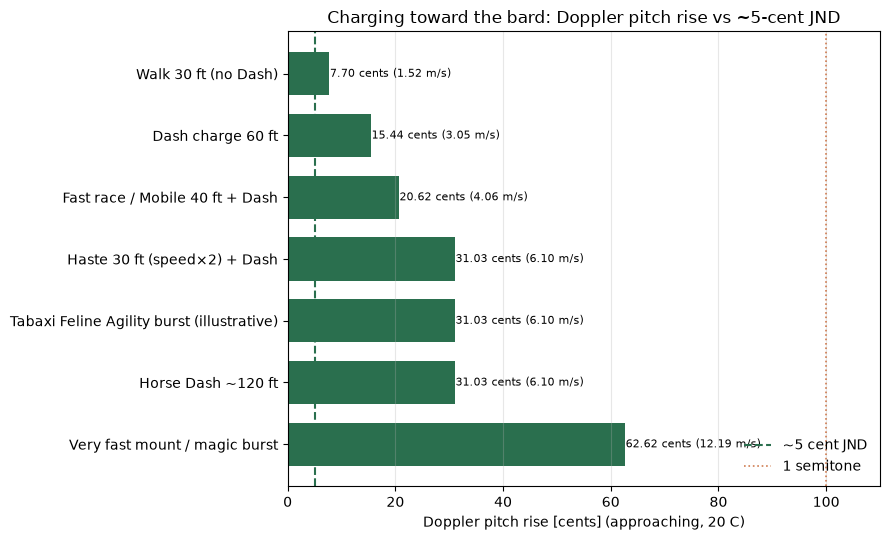

In [9]:
labels = [r[0] for r in rows]
mps_vals = np.array([r[2] for r in rows])
cents_vals = np.array([r[3] for r in rows])

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(labels))
bar_colors = ["#2a6f4e" if c >= CENTS_JND else "#7a7a7a" for c in cents_vals]
ax.barh(y, cents_vals, color=bar_colors, height=0.7)
ax.axvline(CENTS_JND, color="#2a6f4e", ls="--", lw=1.5, label=f"~{CENTS_JND:.0f} cent JND")
ax.axvline(100, color="#c45c26", ls=":", lw=1.2, alpha=0.8, label="1 semitone")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Doppler pitch rise [cents] (approaching, 20 C)")
ax.set_title("Charging toward the bard: Doppler pitch rise vs ~5-cent JND")

for yi, c, m in zip(y, cents_vals, mps_vals):
    ax.text(c + 0.15, yi, f"{c:.2f} cents ({m:.2f} m/s)", va="center", fontsize=8)

ax.set_xlim(0, max(110, float(cents_vals.max()) * 1.25))
ax.invert_yaxis()
ax.legend(frameon=False, loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
plt.show()


### Verdict

Ordinary D&D charges clear a ~5-cent JND:

| Charge style | Speed | Pitch rise (approach) | Vs ~5-cent JND |
|--------------|-------|----------------------|----------------|
| Walk 30 ft/rd | ~1.5 m/s | ~8 cents | just above |
| Dash 60 ft/rd | ~3.0 m/s | ~15 cents | clearly above |
| Haste / fast burst ~120 ft/rd | ~6.1 m/s | ~31 cents | ~1/3 semitone |
| Extreme magic / mount burst ~240 ft/rd | ~12.2 m/s | ~63 cents | still shy of 1 semitone |

A Dash is already enough to notice. A full semitone (~19 m/s ≈ 70 km/h) is still a car problem, not a fighter problem.


## Closing: so, can the bard hear it?

**Yes — a little.** On a common Dash (~3 m/s), the war cry climbs on the order of **~15 cents**: not a new note, but enough that a keen ear could clock the fighter getting closer. A full musical semitone still wants something more like a chariot than a humanoid charge.

### Numbers to keep in your pocket

| Rough speed | Pitch rise (approach) | Everyday feel |
|-------------|----------------------|---------------|
| ~1 m/s | ~5 cents (JND) | walking — “I can tell it moved” |
| ~10 m/s | ~½ semitone | Olympic 100 m pace |
| ~20 m/s | ~1 semitone | city car — “that is a different note” |


## Sources (quick index)

Formulas used above: Doppler $f' = f\,v/(v \mp v_s)$; speed of sound $v \approx 331.3\sqrt{1 + T_C/273.15}$ m/s; cents $r = 2^{c/1200}$.

| Constant / rule | Value used here | Source |
|-----------------|-----------------|--------|
| Doppler (moving source, stationary observer) | see formula above | [HyperPhysics](https://hyperphysics.gsu.edu/hbase/Sound/dopp.html), [Wikipedia](https://en.wikipedia.org/wiki/Doppler_effect) |
| Speed of sound in dry air | ~343 m/s at 20 °C | [HyperPhysics](https://hyperphysics.gsu.edu/hbase/Sound/souspe.html), [OpenStax](https://openstax.org/books/university-physics-volume-1/pages/17-2-speed-of-sound), [Wikipedia](https://en.wikipedia.org/wiki/Speed_of_sound) |
| Cent / equal-tempered semitone | 100 cents = 1 semitone | [HyperPhysics — cents](http://hyperphysics.phy-astr.gsu.edu/hbase/Music/cents.html), [Wikipedia — Cent](https://en.wikipedia.org/wiki/Cent_(music)) |
| Pitch JND | ~5 cents | [HyperPhysics](http://hyperphysics.phy-astr.gsu.edu/hbase/Music/cents.html), [Wikipedia — JND](https://en.wikipedia.org/wiki/Just-noticeable_difference) |
| D&D round length | 6 seconds | [5e SRD — Combat](https://www.5esrd.com/gamemastering/combat/) |
| Typical walking speed | 30 ft / round | [5e SRD — Human](https://www.5esrd.com/races/human/) |
| Dash | +speed movement that turn (e.g. 30→60 ft) | [5e SRD — Combat](https://www.5esrd.com/gamemastering/combat/) |
| Foot → meter | 1 ft = 0.3048 m (exact) | [NIST](https://www.nist.gov/pml/owm/si-units-length) |
| Official SRD | — | [Wizards SRD](https://dnd.wizards.com/resources/systems-reference-document) |
